# 9방향 세부이동 — 모델 비교 추론 (NIMA vs SAMP-Net vs GAIC)

**목적**: `/nima-lateral`(9분할 세부조정 이동)에서 **어떤 모델로 방향을 고르는 게 좋을지** 판단하기 위해,
한 프레임의 9방향 크롭을 세 모델로 각각 점수 매기고 **모델별 순위**·**모델 간 합의도**·**속도**를 비교한다.

- **NIMA**: 전반적 미학 점수 (현재 `/nima-lateral`이 실제로 쓰는 모델)
- **SAMP-Net**: 구도(composition) 전용 점수 (1~5)
- **GAIC**: 크롭 구도 점수 (원래 '이미지+크롭박스' 구조 → 단일 이미지는 전체를 박스로 넣어 그 프레이밍 점수를 구함)
- **TOPIQ**: pyiqa 무참조 이미지 품질 점수 (기본 `topiq_nr`, 0~1, 높을수록 좋음 — 기술적 화질 관점)

대상 폴더: `drone-data/20260709_172807_564/3_detail-move/lateral/1`
(9방향 크롭 `center/up/down/left/right/up-left/up-right/down-left/down-right` + 크롭 전 `original.jpg`)

> 필요 패키지: numpy, pandas, matplotlib, scipy, Pillow (환경에 이미 설치돼 있음).

In [1]:
# ── 셋업: repo root 찾기 + 경로/폰트 ─────────────────────────────
import os, sys, io, time, json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 노트북을 static/에서 실행하든 repo 루트에서 실행하든 동작하도록 main.py 있는 곳을 루트로.
REPO_ROOT = Path(os.getcwd())
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "main.py").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "main.py").exists(), f"repo root를 못 찾음 (cwd={os.getcwd()})"
os.chdir(REPO_ROOT)                 # 모델 가중치 상대경로(config/, models/..) 기준 맞추기
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# 한글 차트 라벨(맥). 폰트 없으면 무시.
try:
    plt.rcParams["font.family"] = "AppleGothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

IMG_DIR = REPO_ROOT / "drone-data/20260709_172807_564/3_detail-move/lateral/1"
assert IMG_DIR.is_dir(), IMG_DIR
print("REPO_ROOT =", REPO_ROOT)
print("IMG_DIR   =", IMG_DIR)

REPO_ROOT = /Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine
IMG_DIR   = /Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine/drone-data/20260709_172807_564/3_detail-move/lateral/1


In [2]:
# ── 이미지 목록 ──────────────────────────────────────────────────
# original.jpg = 크롭 전 전체 프레임(참고용). 나머지 9장이 방향 후보.
DIRECTION_NAMES = ["center", "up", "down", "left", "right",
                   "up-left", "up-right", "down-left", "down-right"]
def is_direction(p: Path) -> bool:
    return p.stem in DIRECTION_NAMES

paths = sorted(IMG_DIR.glob("*.jpg"))
for p in paths:
    tag = "[방향후보]" if is_direction(p) else "[원본프레임]"
    print(f"  {p.name:16s} {tag}")
print(f"\n총 {len(paths)}장 (방향 후보 {sum(is_direction(p) for p in paths)}장)")

  center.jpg       [방향후보]
  down-left.jpg    [방향후보]
  down-right.jpg   [방향후보]
  down.jpg         [방향후보]
  left.jpg         [방향후보]
  original.jpg     [원본프레임]
  right.jpg        [방향후보]
  up-left.jpg      [방향후보]
  up-right.jpg     [방향후보]
  up.jpg           [방향후보]

총 10장 (방향 후보 9장)


## 모델 로드 + 스코어 함수
첫 호출 때 각 모델 가중치를 로드하므로 아래 셀은 처음 한 번만 느립니다(SAMP-Net/ GAIC/ NIMA 순차 로드).

In [3]:
# ── 모델 로드 + 스코어 함수 ─────────────────────────────────────
from models.nima import run_nima_score
from models.sampnet import score_image as samp_score_image
from models.topiq import run_topiq_score
from models import gaic

def score_nima(path: Path) -> float:
    return float(run_nima_score(path.read_bytes(), path.name)["score"])

def score_samp(path: Path) -> float:
    return float(samp_score_image(path.read_bytes())["score"])

def score_topiq(path: Path) -> float:
    return float(run_topiq_score(path.read_bytes(), path.name)["score"])

def score_gaic(path: Path) -> float:
    # GAIC는 '이미지 + 크롭박스' 구조라, 단일 이미지는 전체(0,0,W,H)를 박스로 넣어
    # 그 프레이밍 자체의 구도 점수를 얻는다(근사).
    img = Image.open(path).convert("RGB")
    W, H = img.size
    return float(gaic.score_boxes(img, [[0, 0, W, H]])[0])

# 워밍업(가중치 로드) — 타이밍에서 로드시간 제외. TOPIQ는 첫 실행 시 가중치 다운로드(~170MB).
_wp = paths[0]
_ = score_nima(_wp); _ = score_samp(_wp); _ = score_topiq(_wp); _ = score_gaic(_wp)
print("4개 모델 로드 완료")

Loading pretrained model NIMA from /Users/yujin/.cache/torch/hub/pyiqa/NIMA_InceptionV2_ava-b0c77c00.pth


[sampnet] loading resnet18 on cpu (/Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine/models/samp_net/models/samp_net.pth)
Saliency-aware Multi-Pattern Pooling pattern: [1, 2, 3, 4, 5, 6, 7, 8], fusion manner: sum, dropout: 0.5


Loading pretrained model CFANet from /Users/yujin/.cache/torch/hub/pyiqa/cfanet_nr_koniq_res50-9a73138b.pth


[gaic] loading mobilenetv2 on cpu (/Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine/models/gaic_bundle/pretrained_models/GAIC-mobilenetv2-reddim16.pth)
4개 모델 로드 완료


In [4]:
# ── 전체 스코어링 (+ 장당 추론시간) ─────────────────────────────
rows = []
for p in paths:
    t0 = time.perf_counter(); nima = score_nima(p);   t1 = time.perf_counter()
    samp = score_samp(p);                              t2 = time.perf_counter()
    topiq = score_topiq(p);                            t3 = time.perf_counter()
    gaic_s = score_gaic(p);                            t4 = time.perf_counter()
    rows.append({
        "name": p.stem, "is_direction": is_direction(p),
        "nima": round(nima, 4), "samp": round(samp, 4),
        "topiq": round(topiq, 4), "gaic": round(gaic_s, 4),
        "nima_ms": round((t1 - t0) * 1000, 1),
        "samp_ms": round((t2 - t1) * 1000, 1),
        "topiq_ms": round((t3 - t2) * 1000, 1),
        "gaic_ms": round((t4 - t3) * 1000, 1),
    })
df = pd.DataFrame(rows)
df

,name,is_direction,nima,samp,topiq,gaic,nima_ms,samp_ms,topiq_ms,gaic_ms
0,center,True,4.2996,2.4674,0.6586,3.5933,123.9,29.6,89.8,66.8
1,down-left,True,4.7188,2.2818,0.6707,2.9681,119.9,27.5,85.3,72.9
2,down-right,True,4.2097,2.1941,0.6461,3.6035,126.9,28.3,85.9,64.1
3,down,True,4.3145,2.3011,0.6481,3.2416,114.0,25.4,82.1,64.3
4,left,True,4.4080,2.3472,0.6788,3.3662,117.0,27.0,81.7,64.2
5,original,False,4.9648,2.4961,0.7225,3.3199,112.0,30.8,250.9,64.9
6,right,True,4.1769,2.4931,0.6624,3.6302,111.1,26.9,80.6,70.2
7,up-left,True,4.2557,2.7382,0.6585,3.3512,121.5,27.0,86.0,66.0
8,up-right,True,4.4445,2.9188,0.6413,3.9120,121.8,27.1,83.1,64.2
9,up,True,4.4464,2.8562,0.6446,3.5625,116.5,27.4,85.7,61.9


## 방향 후보 9장 — 모델별 순위 (1 = 최고)
`original.jpg`(전체 프레임)는 스케일이 달라 순위 비교에서 제외하고, 9방향 크롭만 랭킹한다.

In [5]:
# ── 방향 후보만 뽑아 모델별 등수 매기기 ─────────────────────────
dirs = df[df.is_direction].copy().reset_index(drop=True)
MODELS = ["nima", "samp", "topiq", "gaic"]   # 모두 '높을수록 좋음'
for m in MODELS:
    dirs[m + "_rank"] = dirs[m].rank(ascending=False, method="min").astype(int)

def ranked(model: str) -> pd.DataFrame:
    return (dirs.sort_values(model, ascending=False)[["name", model, model + "_rank"]]
                .reset_index(drop=True))

print("── NIMA 순위 ──");   display(ranked("nima"))
print("── SAMP 순위 ──");   display(ranked("samp"))
print("── TOPIQ 순위 ──");  display(ranked("topiq"))
print("── GAIC 순위 ──");   display(ranked("gaic"))

── NIMA 순위 ──


,name,nima,nima_rank
0,down-left,4.7188,1
1,up,4.4464,2
2,up-right,4.4445,3
3,left,4.4080,4
4,down,4.3145,5
5,center,4.2996,6
6,up-left,4.2557,7
7,down-right,4.2097,8
8,right,4.1769,9


── SAMP 순위 ──


,name,samp,samp_rank
0,up-right,2.9188,1
1,up,2.8562,2
2,up-left,2.7382,3
3,right,2.4931,4
4,center,2.4674,5
5,left,2.3472,6
6,down,2.3011,7
7,down-left,2.2818,8
8,down-right,2.1941,9


── TOPIQ 순위 ──


,name,topiq,topiq_rank
0,left,0.6788,1
1,down-left,0.6707,2
2,right,0.6624,3
3,center,0.6586,4
4,up-left,0.6585,5
5,down,0.6481,6
6,down-right,0.6461,7
7,up,0.6446,8
8,up-right,0.6413,9


── GAIC 순위 ──


,name,gaic,gaic_rank
0,up-right,3.9120,1
1,right,3.6302,2
2,down-right,3.6035,3
3,center,3.5933,4
4,up,3.5625,5
5,left,3.3662,6
6,up-left,3.3512,7
7,down,3.2416,8
8,down-left,2.9681,9


In [6]:
# ── 통합 비교표(방향별 세 모델 점수·등수 한눈에) ────────────────
cmp = dirs[["name", "nima", "nima_rank", "samp", "samp_rank",
            "topiq", "topiq_rank", "gaic", "gaic_rank"]].copy()
cmp = cmp.sort_values("nima_rank").reset_index(drop=True)
cmp

,name,nima,nima_rank,samp,samp_rank,topiq,topiq_rank,gaic,gaic_rank
0,down-left,4.7188,1,2.2818,8,0.6707,2,2.9681,9
1,up,4.4464,2,2.8562,2,0.6446,8,3.5625,5
2,up-right,4.4445,3,2.9188,1,0.6413,9,3.9120,1
3,left,4.4080,4,2.3472,6,0.6788,1,3.3662,6
4,down,4.3145,5,2.3011,7,0.6481,6,3.2416,8
5,center,4.2996,6,2.4674,5,0.6586,4,3.5933,4
6,up-left,4.2557,7,2.7382,3,0.6585,5,3.3512,7
7,down-right,4.2097,8,2.1941,9,0.6461,7,3.6035,3
8,right,4.1769,9,2.4931,4,0.6624,3,3.6302,2


## 검증: `report.json`(실제 `/nima-lateral` 로그)와 대조
저장된 방향 크롭 이미지를 NIMA로 다시 매긴 값이, 요청 당시 기록된 `report.json`의 점수와 (JPEG 재압축 오차 범위 내에서) 일치하는지 확인.

In [7]:
# ── report.json 로그와 NIMA 재현 대조 ──────────────────────────
rep = json.loads((IMG_DIR / "report.json").read_text())
rep_scores = rep["scores"]
chk = dirs[["name", "nima"]].copy()
chk["report_nima"] = chk["name"].map(rep_scores)
chk["diff"] = (chk["nima"] - chk["report_nima"]).round(4)
print("nima-lateral이 실제 고른 방향:", rep["best_direction"], "(score", rep["best_score"], ")")
print("center가 best였나:", rep["is_center_best"], "| score_margin:", rep["score_margin"])
chk.sort_values("report_nima", ascending=False).reset_index(drop=True)

nima-lateral이 실제 고른 방향: down-left (score 4.7188 )
center가 best였나: False | score_margin: 0.4192


,name,nima,report_nima,diff
0,down-left,4.7188,4.7188,0.0
1,up,4.4464,4.4464,0.0
2,up-right,4.4445,4.4445,0.0
3,left,4.4080,4.4080,0.0
4,down,4.3145,4.3145,0.0
5,center,4.2996,4.2996,0.0
6,up-left,4.2557,4.2557,0.0
7,down-right,4.2097,4.2097,0.0
8,right,4.1769,4.1769,0.0


## 모델 간 합의도 — 순위 상관 + top-1 일치
세 모델이 **같은 방향을 좋다고 보는지**가 핵심. Spearman 순위상관(1=완전 동일 순위, 0=무관, 음수=반대)과 각 모델의 1등 방향을 본다.

In [8]:
# ── Spearman 순위상관 + top-1 방향 ─────────────────────────────
from scipy.stats import spearmanr

corr = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for a in MODELS:
    for b in MODELS:
        corr.loc[a, b] = round(float(spearmanr(dirs[a], dirs[b]).correlation), 3)
print("── 모델 간 순위 상관 (Spearman) ──")
display(corr)

top1 = {m: dirs.sort_values(m, ascending=False).iloc[0]["name"] for m in MODELS}
print("각 모델의 1등 방향:", top1)
print("네 모델 top-1 완전 일치?", len(set(top1.values())) == 1)
for m in ["samp", "topiq", "gaic"]:
    print(f"NIMA vs {m.upper()} top-1 일치? {top1['nima'] == top1[m]}")

── 모델 간 순위 상관 (Spearman) ──


,nima,samp,topiq,gaic
nima,1.000,0.133,-0.067,-0.400
samp,0.133,1.000,-0.433,0.433
topiq,-0.067,-0.433,1.000,-0.433
gaic,-0.400,0.433,-0.433,1.000


각 모델의 1등 방향: {'nima': 'down-left', 'samp': 'up-right', 'topiq': 'left', 'gaic': 'up-right'}
네 모델 top-1 완전 일치? False
NIMA vs SAMP top-1 일치? False
NIMA vs TOPIQ top-1 일치? False
NIMA vs GAIC top-1 일치? False


## 시각화 1 — 방향별 정규화 점수(모델별)
모델마다 점수 스케일이 달라 그대로는 못 겹치므로, 각 모델 점수를 **min-max로 0~1 정규화**해 방향별로 겹쳐 본다.

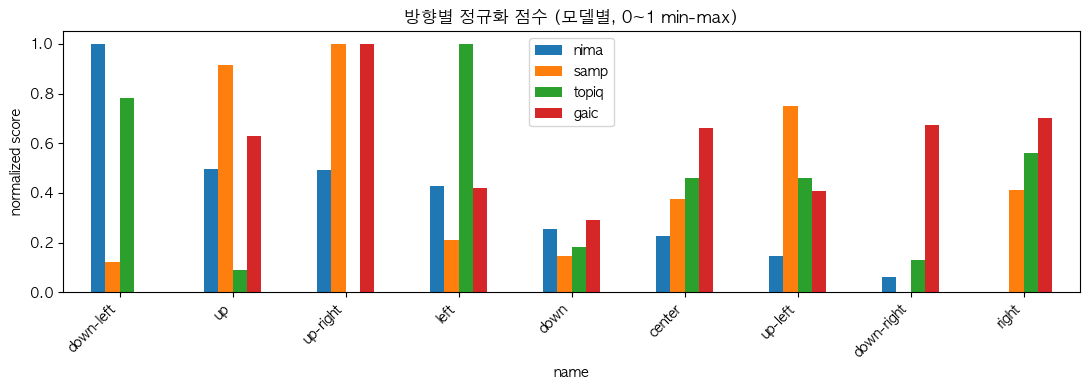

In [9]:
# ── 정규화 막대그래프 ───────────────────────────────────────────
norm = dirs.copy()
for m in MODELS:
    lo, hi = norm[m].min(), norm[m].max()
    norm[m + "_n"] = (norm[m] - lo) / (hi - lo) if hi > lo else 0.5

order = dirs.sort_values("nima", ascending=False)["name"].tolist()
norm = norm.set_index("name").loc[order]
ax = norm[[m + "_n" for m in MODELS]].plot(kind="bar", figsize=(11, 4))
ax.set_title("방향별 정규화 점수 (모델별, 0~1 min-max)")
ax.set_ylabel("normalized score"); ax.legend(MODELS)
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

## 시각화 2 — 썸네일 + 3모델 점수/등수
각 방향 크롭 이미지에 세 모델의 점수와 등수를 함께 표시(정성 확인용).

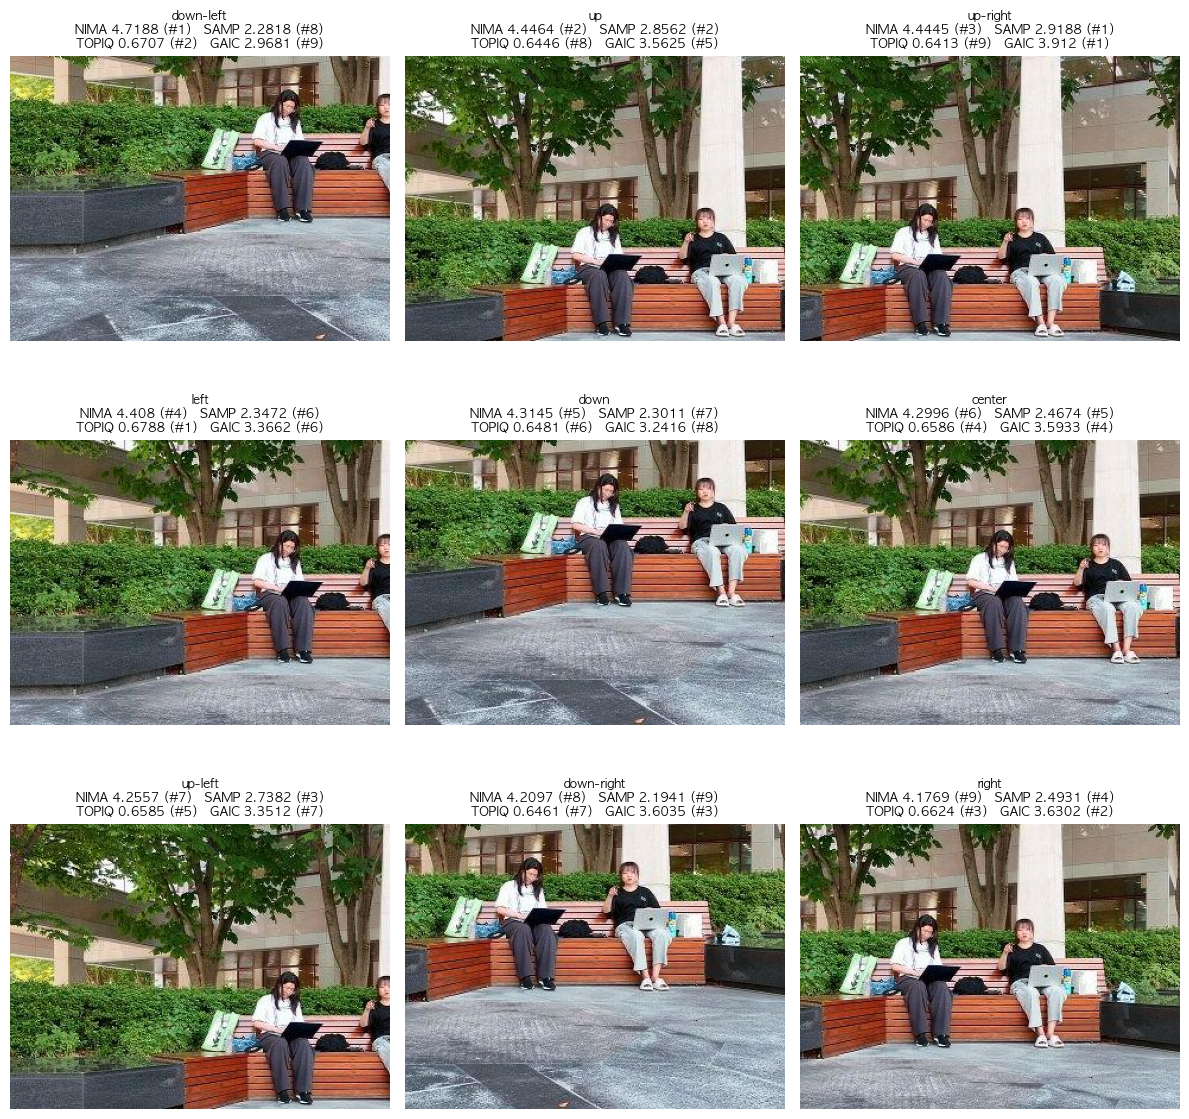

In [10]:
# ── 썸네일 그리드 (NIMA 순 정렬) ────────────────────────────────
grid = dirs.sort_values("nima", ascending=False).reset_index(drop=True)
n = len(grid); ncols = 3; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
for ax, (_, r) in zip(axes.flat, grid.iterrows()):
    ax.imshow(Image.open(IMG_DIR / f"{r['name']}.jpg")); ax.axis("off")
    ax.set_title(
        f"{r['name']}\n"
        f"NIMA {r['nima']} (#{r['nima_rank']})   SAMP {r['samp']} (#{r['samp_rank']})\n"
        f"TOPIQ {r['topiq']} (#{r['topiq_rank']})   GAIC {r['gaic']} (#{r['gaic_rank']})",
        fontsize=9)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 속도 비교 (실시간 드론 제어에서 중요)
9방향을 매번 평가하므로 장당 추론시간이 곧 반응성. (CPU 기준, 첫 로드 제외)

In [11]:
# ── 장당 평균 추론시간 ──────────────────────────────────────────
avg = df[["nima_ms", "samp_ms", "topiq_ms", "gaic_ms"]].mean().round(1)
print("장당 평균 추론시간 (ms):")
print(avg.to_string())
print(f"\n9방향 1세트 예상 소요(ms): "
      f"NIMA {avg['nima_ms']*9:.0f} | SAMP {avg['samp_ms']*9:.0f} | "
      f"TOPIQ {avg['topiq_ms']*9:.0f} | GAIC {avg['gaic_ms']*9:.0f}")

장당 평균 추론시간 (ms):
nima_ms     118.5
samp_ms      27.7
topiq_ms    101.1
gaic_ms      66.0

9방향 1세트 예상 소요(ms): NIMA 1066 | SAMP 249 | TOPIQ 910 | GAIC 594


## 해석 가이드 (결론 내리는 법)

- **top-1 일치 여부**: 세 모델이 같은 방향을 1등으로 뽑으면 → 어느 모델을 써도 이동 결정은 같음. 갈리면 아래로 판단.
- **Spearman 상관**: NIMA와 SAMP/GAIC의 순위상관이 높으면 대체 가능. 낮거나 음수면 서로 다른 걸 본다는 뜻 → 어떤 게 "구도상 맞는지" 썸네일로 정성 확인.
- **정성 판단(썸네일)**: 주 피사체가 삼분할/중앙에 잘 놓이고 잘림 없는 방향을 사람 눈으로 고른 뒤, 그와 top-1이 맞는 모델을 선호.
- **속도**: 세부이동은 매 스텝 9장 평가라 장당 시간이 중요. 품질이 비슷하면 빠른 모델.
- **성격 차이**: NIMA=전반 미학 / SAMP=구도 전용(1~5) / GAIC=크롭 구도 / TOPIQ=무참조 기술적 화질(선명도·왜곡 등). "세부이동=구도 정렬" 목적엔 SAMP/GAIC가 이론상 더 맞고, NIMA는 전반 미학, TOPIQ는 화질 관점이라 방향(구도) 선택보다는 흐림·품질 필터로 보조하기 좋다.

> 한 세션(lateral/1)만으로 일반화는 이르다. `IMG_DIR`만 다른 세션/인덱스로 바꿔 여러 케이스에서 top-1 일치율·상관을 모아 보면 판단이 단단해진다.